In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#я это потом делал в Colab, так что датасет тут загружен через Cagglehub:
import kagglehub
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

import os

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Path to dataset files: /kaggle/input/credit-risk-dataset


**Получение информации о датасете, группировка данных**

Здесь нужно получить информацию о датасете: определить количество уникальных записей и количество признаков у них, затем нужно удалить несущественные данные.

После этого производится группировка данных по определённым признакам. В нашем случае мы выяснили, что наибольший средний размер - у кредитов на ремонт дома, наименьший - у кредитов на лечение. Наибольшая ставка - у кредитов на ремонт, наименьшая - у венчурных.

Также производится вывод трёх записей из датасета.


In [11]:
df = pd.read_csv(os.path.join(path, "credit_risk_dataset.csv"))

print(f"Размер датасета: {df.shape[0]} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()
#в данном датасете нет несущественных данных по типу идентификатора или фамилии, поэтому чистка данных не требуется
#общий вид строки для удаления ненужных данных
#df = df.drop(["имя_признака1", "имя_признака2"], axis = 1)


economic_stats = df.groupby("loan_intent")[["loan_amnt", "loan_int_rate"]].mean()
print("\nСредние размер и ставка кредита в зависисмости от назначения:", economic_stats)

print("\nПервые 3 строки данных")
df.head(3)

Размер датасета: 32581 клиентов и 12 признаков
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3


**Визуализация**

Здесь строится график, позволяющий визуализировать данные для выявления связи между ними. Здесь мы видим, что кредиты, размер которых больше относительно дохода клиента, чаще выплачивают с просрочкой (дефолт).

<function matplotlib.pyplot.show(close=None, block=None)>

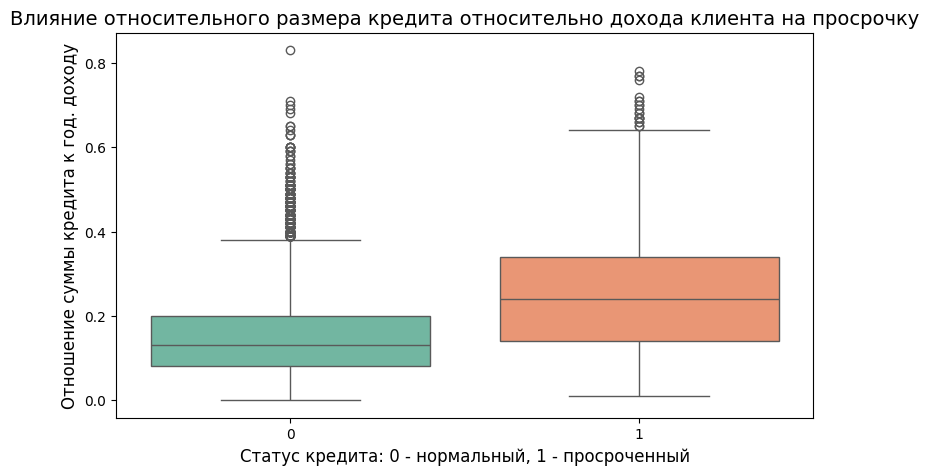

In [17]:
plt.figure(figsize=(9,5))

sns.boxplot(x="loan_status", y="loan_percent_income", data=df, palette="Set2", legend=False, hue = "loan_status")
plt.title("Влияние относительного размера кредита относительно дохода клиента на просрочку", fontsize=14)
plt.xlabel("Статус кредита: 0 - нормальный, 1 - просроченный", fontsize=12)
plt.ylabel("Отношение суммы кредита к год. доходу", fontsize=12)
plt.show


**Подготовка признаков**

Здесь необходимо выделить категоральные (нечисловые) признаки, чтобы переделать их в логический вид. После обработки они будут представлены в виде "является ли признак вариантом 1, вариантом 2 и т.д."

In [13]:
y = df["loan_status"]
x = pd.get_dummies(df.drop("loan_status", axis=1),columns=["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"], drop_first=True)
print("Данные после обработки категоральных признаков")
x.head(3)

Данные после обработки категоральных признаков


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False


**Масштабирование и разбиение**

Здесь производится приведение числовых признаков к единой размерности, чтобы они имели одинаковый вес для системы


In [14]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size = 0.2, random_state = 42, stratify = y)

numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]

scaler = StandardScaler()
xtrain[numeric_cols] = scaler.fit_transform(xtrain[numeric_cols])
xtest[numeric_cols] = scaler.transform(xtest[numeric_cols])
xtrain.head(3)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
32561,4.135701,1.370488,0.320087,-0.091303,0.151990,-0.939279,4.499921,False,False,False,...,False,False,False,True,False,False,False,False,False,False
8376,-1.046077,-0.092816,-0.429619,-0.327237,-0.187998,-0.473684,-0.929115,False,False,True,...,False,False,False,True,False,False,False,False,False,False
11563,-0.575006,0.208453,-1.179325,0.380563,-1.260508,-0.101208,-0.435567,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Обучение модели и оценка экономического эффекта**

Здесь производится загрузка данных для обучения модели и тестовый запуск для выяснения способности модели предсказывать просрочку кредита на основе признаков

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(xtrain, ytrain)
ypred=model.predict(xtest)
accuracy = accuracy_score(ytest, ypred)*100
print(f"Общая точность модели (Accuracy): {accuracy:.2f}%\n")

Общая точность модели (Accuracy): 92.13%

